In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

DEFINE STATE

In [19]:
class EquationState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discriminant: int
    result: str

DEFINE FUNCTION

In [20]:
def mainEquation(state: EquationState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    equation = f"{a}x^2 + {b}x + {c}"
    state["equation"] = equation    
    return {"equation": equation}
def calculateDiscriminant(state: EquationState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    b = state["b"]
    c = state["c"]
    discriminant = b**2 - 4*a*c
    state["discriminant"] = discriminant
    return {"discriminant": discriminant}
def discriminatePOSITIVE(state: EquationState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    discriminant = state["discriminant"]
    rootA = (-b + discriminant**0.5) / (2 * a)
    rootB = (-b - discriminant**0.5) / (2 * a)
    result = f"Two real roots: {rootA} and {rootB}"
    return {"result": result}
def discriminateZERO(state: EquationState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    discriminant = state["discriminant"]
    root = -b / (2 * a)
    result = f"One real root: {root}"
    return {"result": result}
def discriminateNEGATIVE(state: EquationState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    discriminant = state["discriminant"]
    realPart = -b / (2 * a)
    imaginaryPart = (abs(discriminant)**0.5) / (2 * a)
    result = f"Two complex roots: {realPart} + {imaginaryPart}i and {realPart} - {imaginaryPart}i"
    return {"result": result}

ROUTING FUNCTION

In [21]:
def CHECK_DISCRIMINANT(state: EquationState) -> Literal["discriminatePOSITIVE", "discriminateZERO", "discriminateNEGATIVE"]:
    discriminant = state["discriminant"]
    if discriminant > 0:
        return "discriminatePOSITIVE"
    elif discriminant == 0:
        return "discriminateZERO"
    else:
        return "discriminateNEGATIVE"

DEFINE GRAPH

In [22]:
graph = StateGraph(EquationState)

DEFINE NODES

In [23]:
graph.add_node("mainEquation", mainEquation)
graph.add_node("calculateDiscriminant", calculateDiscriminant)
graph.add_node("discriminatePOSITIVE", discriminatePOSITIVE)
graph.add_node("discriminateZERO", discriminateZERO)    
graph.add_node("discriminateNEGATIVE", discriminateNEGATIVE)

DEFINE EDGES

In [24]:
graph.add_edge(START, "mainEquation")
graph.add_edge("mainEquation", "calculateDiscriminant")

graph.add_conditional_edges("calculateDiscriminant", CHECK_DISCRIMINANT)

graph.add_edge("discriminatePOSITIVE", END)
graph.add_edge("discriminateZERO", END) 
graph.add_edge("discriminateNEGATIVE", END)

GRAPH COMPILE

In [25]:
workflow = graph.compile()

EXECUTE PHASE

In [26]:
initial_state = {
    "a": 4,
    "b": 2,
    "c": 5
}
workflow.invoke(initial_state)

{'a': 4,
 'b': 2,
 'c': 5,
 'equation': '4x^2 + 2x + 5',
 'discriminant': -76,
 'result': 'Two complex roots: -0.25 + 1.0897247358851685i and -0.25 - 1.0897247358851685i'}

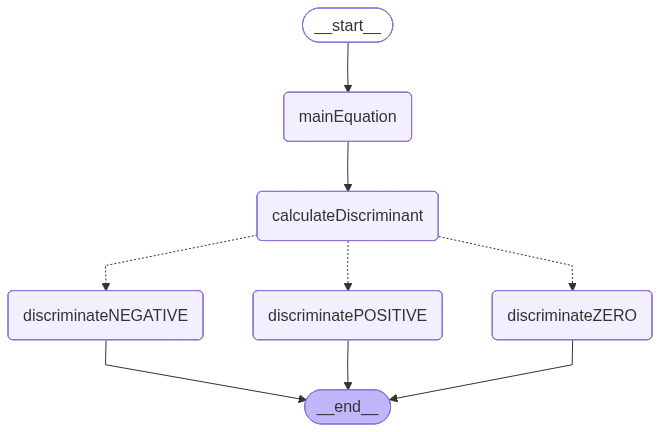

In [27]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())